# Tutorial 01 - Real market data and the De-Time feature factory

This tutorial builds the data and feature layer used by the rest of the quant tutorial. The working idea is simple: a price or volume series is decomposed into trend, cycle and residual structure, then each component becomes a trading feature with a clear job.

The rendered notebook uses the bundled historical GOOG Yahoo Finance sample from the reference algorithmic-trading material. The same functions also support Yahoo Finance downloads through `yfinance`; the downloader script writes cached OHLCV panels for larger universes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from examples.quant_trading.data import (
    load_sample_goog_ohlcv,
    market_data_manifest,
    ohlcv_audit_report,
)
from examples.quant_trading.decomposition_features import (
    build_feature_table,
    estimate_dominant_period,
    feature_coverage_report,
)
from examples.quant_trading.features import walkforward_decompose_ohlcv
from examples.quant_trading.validation import write_run_audit

pd.set_option("display.max_columns", 20)
REPORT_DIR = Path("examples/quant_trading/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load an auditable OHLCV table

For the documentation build we use a historical GOOG OHLCV table already stored in the repository. A live run can replace this object with `fetch_yahoo_ohlcv_panel([...])` or the command-line downloader.


In [2]:
ohlcv_single = load_sample_goog_ohlcv(trim_start="2014-01-01")
ticker = ohlcv_single.attrs.get("symbol", "GOOG")
ohlcv = {
    field: ohlcv_single[[field]].rename(columns={field: ticker})
    for field in ["Open", "High", "Low", "Close", "Volume"]
}
close = ohlcv["Close"]
volume = ohlcv["Volume"]

audit = ohlcv_audit_report(ohlcv)
manifest = market_data_manifest(
    tickers=[ticker],
    start=str(close.index.min().date()),
    end=str(close.index.max().date()),
    interval="1d",
    source=ohlcv_single.attrs.get("source", "bundled historical OHLCV sample"),
)

display(audit)
display(manifest)


,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,GOOG,2014-01-02,2018-01-02,1008,0.0,0.0,0.0,491.201416,1077.140015,1624450.0


,source,tickers,start,end,interval,auto_adjust,archived_or_vendor_market_data,research_note
0,Learn-Algorithmic-Trading GOOG Yahoo Finance e...,GOOG,2014-01-02,2018-01-02,1d,True,True,Educational source; replace with licensed poin...


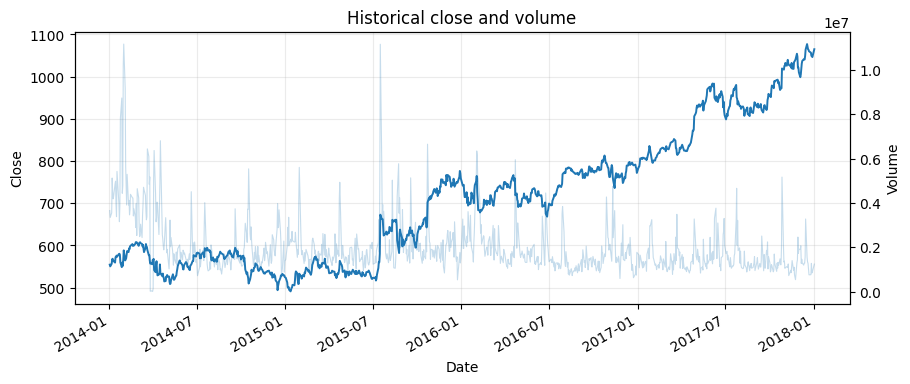

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4))
close[ticker].plot(ax=ax1, linewidth=1.4, label="close")
ax1.set_title("Historical close and volume")
ax1.set_ylabel("Close")
ax2 = ax1.twinx()
volume[ticker].plot(ax=ax2, alpha=0.25, linewidth=0.8, label="volume")
ax2.set_ylabel("Volume")
ax1.grid(True, alpha=0.25)
plt.show()


## 2. Estimate the dominant trading horizon

The period estimator chooses from interpretable trading horizons. In the first two tutorials the selected value is a feature, not a tuning secret: it is written into the audit table and shown in the notebook.


In [4]:
period_estimate = estimate_dominant_period(close[ticker], candidates=(21, 42, 63, 126), use_log=True)
period_summary = pd.DataFrame([period_estimate.__dict__])
display(period_summary)


,period,score,source,candidates
0,126,8.603413,acf_periodogram_candidates,"(21, 42, 63, 126)"


## 3. Build walk-forward price and volume features

The feature factory recomputes decomposition on rolling training windows and carries the latest component state forward until the next recomputation date. Price and volume are handled with the same component vocabulary.


In [5]:
features = walkforward_decompose_ohlcv(
    ohlcv,
    method="STL",
    period="auto",
    period_candidates=(21, 42, 63, 126),
    train_window=252,
    step=21,
    z_window=63,
)
coverage = feature_coverage_report(features)
display(coverage.sort_values(["feature", "asset"]).head(18))


,feature,asset,observations,non_null,coverage,first_valid,last_valid
16,component_stability,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
1,cycle,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
9,cycle_amplitude,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
10,cycle_position,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
8,cycle_slope,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
11,cycle_turn_up,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
7,cycle_z,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
15,reconstruction_error,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
2,residual,GOOG,1008,757,0.750992,2014-12-31,2018-01-02
13,residual_abs_z,GOOG,1008,757,0.750992,2014-12-31,2018-01-02


In [6]:
feature_table = build_feature_table(close, features)
latest = feature_table.tail(5)
display(latest)


,component_stability,cycle,cycle_amplitude,cycle_position,cycle_slope,cycle_turn_up,cycle_z,realized_vol_20,reconstruction_error,residual,...,volume_residual_abs_z,volume_residual_vol,volume_residual_z,volume_selected_period,volume_shock,volume_trend,volume_trend_acceleration,volume_trend_gap,volume_trend_slope,volume_trend_strength
,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,...,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-26,0.988768,-0.008012,0.019440,-0.412121,-0.006565,0.0,-0.558198,0.151519,0.0,-0.001348,...,1.062265,0.220935,1.062265,21.0,1.062265,13.746776,-0.000101,0.613382,-0.016067,-0.043385
2017-12-27,0.988768,-0.008012,0.019440,-0.412121,-0.006565,0.0,-0.558198,0.151818,0.0,-0.001348,...,1.062265,0.220935,1.062265,21.0,1.062265,13.746776,-0.000101,0.613382,-0.016067,-0.043385
2017-12-28,0.988768,-0.008012,0.019440,-0.412121,-0.006565,0.0,-0.558198,0.122569,0.0,-0.001348,...,1.062265,0.220935,1.062265,21.0,1.062265,13.746776,-0.000101,0.613382,-0.016067,-0.043385
2017-12-29,0.988768,-0.008012,0.019440,-0.412121,-0.006565,0.0,-0.558198,0.122892,0.0,-0.001348,...,1.062265,0.220935,1.062265,21.0,1.062265,13.746776,-0.000101,0.613382,-0.016067,-0.043385
2018-01-02,0.992602,-0.008287,0.018258,-0.453850,0.003429,1.0,-0.408674,0.127032,0.0,-0.008367,...,0.359667,0.250410,-0.359667,21.0,0.359667,14.038200,-0.000499,-0.009514,-0.005891,-0.016957


## 4. Inspect the structural components

The first chart shows the original close together with the decomposed trend. The second chart isolates the cycle. The third chart shows residual pressure after trend and cycle have been removed.


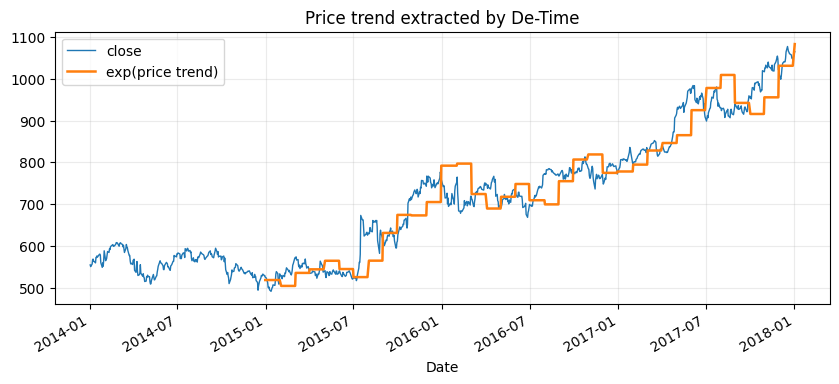

In [7]:
trend = features["trend"][ticker]
fig, ax = plt.subplots(figsize=(10, 4))
close[ticker].plot(ax=ax, linewidth=1.0, label="close")
np.exp(trend).plot(ax=ax, linewidth=1.8, label="exp(price trend)")
ax.set_title("Price trend extracted by De-Time")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


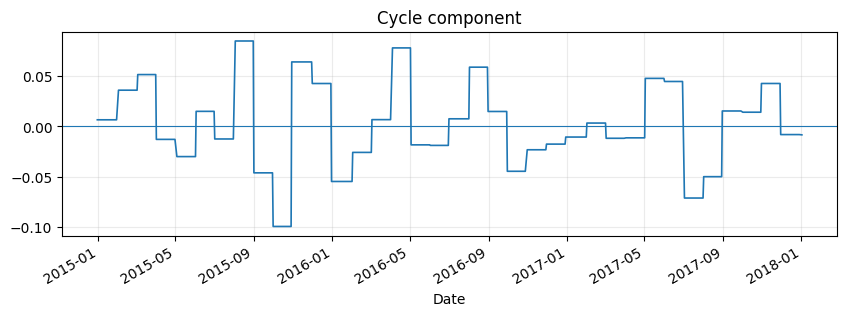

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
features["cycle"][ticker].plot(ax=ax, linewidth=1.2)
ax.axhline(0, linewidth=0.8)
ax.set_title("Cycle component")
ax.grid(True, alpha=0.25)
plt.show()


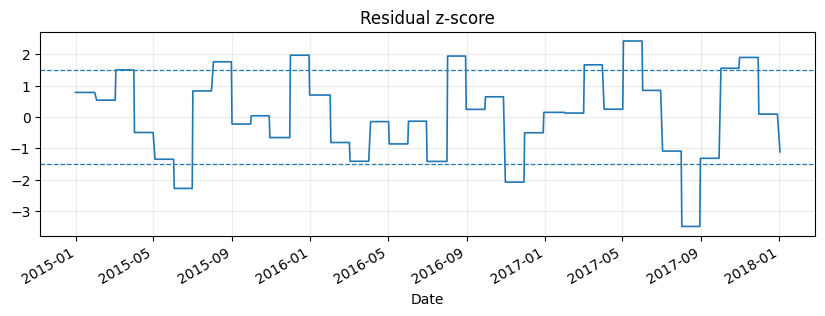

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
features["residual_z"][ticker].plot(ax=ax, linewidth=1.2)
ax.axhline(1.5, linestyle="--", linewidth=0.9)
ax.axhline(-1.5, linestyle="--", linewidth=0.9)
ax.set_title("Residual z-score")
ax.grid(True, alpha=0.25)
plt.show()


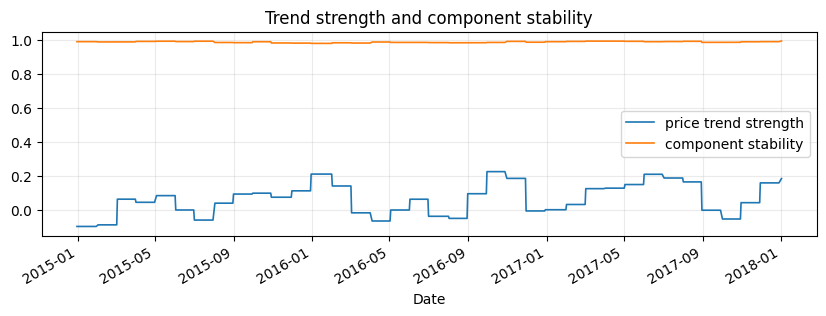

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
features["trend_strength"][ticker].plot(ax=ax, linewidth=1.2, label="price trend strength")
features["component_stability"][ticker].plot(ax=ax, linewidth=1.2, label="component stability")
ax.set_title("Trend strength and component stability")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


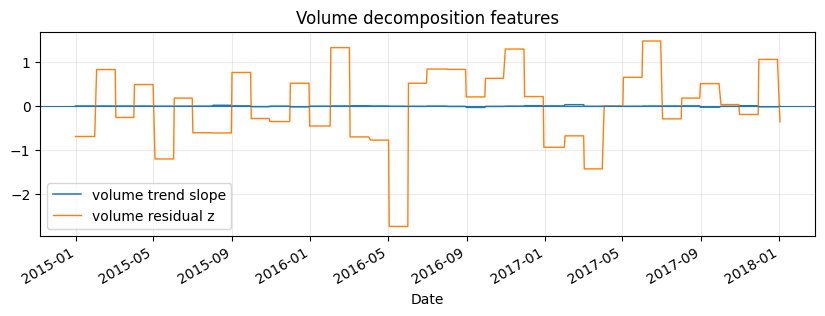

In [11]:
fig, ax = plt.subplots(figsize=(10, 3))
features["volume_trend_slope"][ticker].plot(ax=ax, linewidth=1.1, label="volume trend slope")
features["volume_residual_z"][ticker].plot(ax=ax, linewidth=1.0, label="volume residual z")
ax.axhline(0, linewidth=0.8)
ax.set_title("Volume decomposition features")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


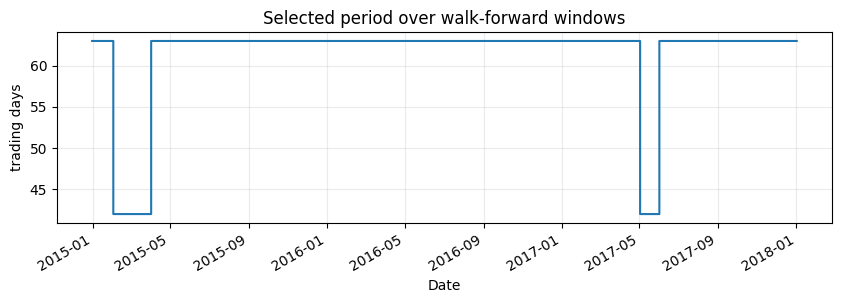

In [12]:
fig, ax = plt.subplots(figsize=(10, 2.8))
features["selected_period"][ticker].dropna().plot(ax=ax, drawstyle="steps-post")
ax.set_title("Selected period over walk-forward windows")
ax.set_ylabel("trading days")
ax.grid(True, alpha=0.25)
plt.show()


## 5. Persist the audit outputs

Tutorial 01 writes compact CSV files that later notebooks can reuse: a market-data manifest, a data-audit table and a tail sample of the feature table.


In [13]:
feature_table.tail(60).to_csv(REPORT_DIR / "column_01_feature_table_tail.csv")
paths = write_run_audit(
    REPORT_DIR,
    data_manifest=manifest,
    audit=audit,
    strategy_stats=None,
    prefix="column_01",
)
summary = pd.DataFrame({"artifact": list(paths), "path": [str(p) for p in paths.values()]})
display(summary)


,artifact,path
0,manifest,examples\quant_trading\reports\column_01_marke...
1,data_audit,examples\quant_trading\reports\column_01_data_...
